In [2]:
import pandas as pd

df = pd.read_csv('/content/city_day.csv')

print(df.head())
print(df.shape)
print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: '/content/city_day.csv'

In [3]:
from google.colab import files

uploaded = files.upload()

Saving city_day.csv to city_day.csv


In [4]:
import os

print(os.listdir())

['.config', 'city_day.csv', 'sample_data']


In [5]:
import pandas as pd

df = pd.read_csv('city_day.csv')

print(df.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


In [6]:
print(df.shape)

(29531, 16)


Dataset Shape:
(29531, 16)

Missing Values:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Shape After Cleaning:
(24850, 16)

Dataset Statistics:
                                Date         PM2.5          PM10  \
count                          24850  24172.000000  17764.000000   
mean   2018-07-24 18:51:25.714285568     67.476613    118.454435   
min              2015-01-01 00:00:00      0.040000      0.030000   
25%              2017-08-16 00:00:00     29.000000     56.777500   
50%              2018-11-05 00:00:00     48.785000     96.180000   
75%              2019-10-11 00:00:00     80.925000    150.182500   
max              2020-07-01 00:00:00    914.940000    917.080000   
std                    

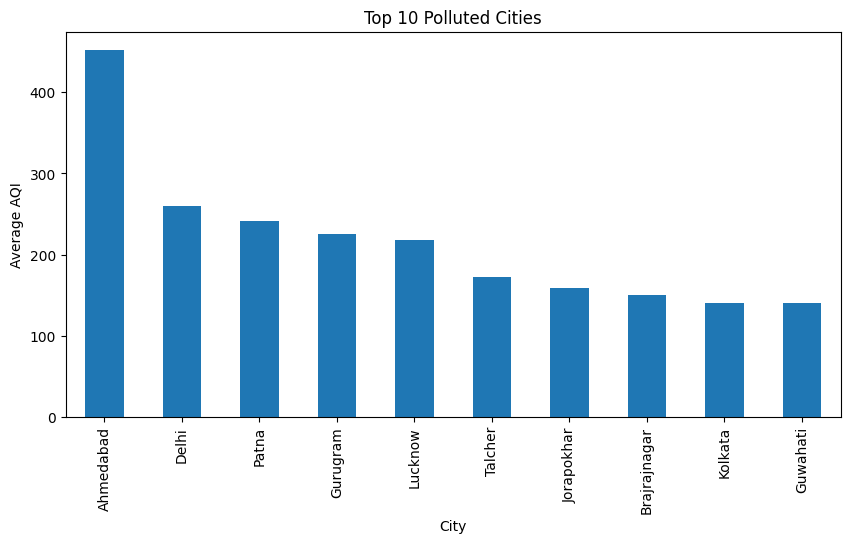

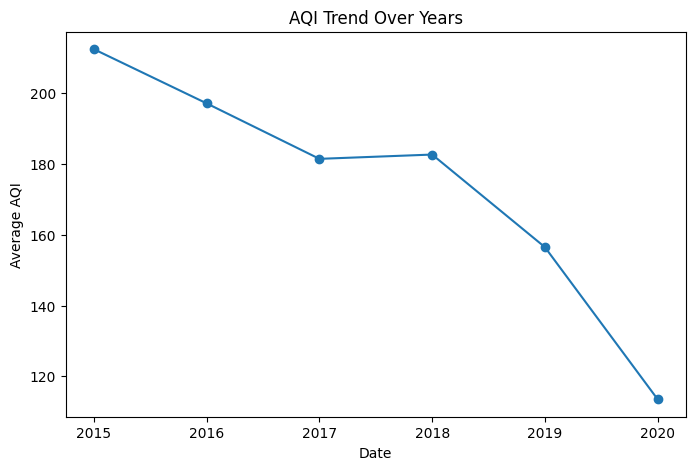

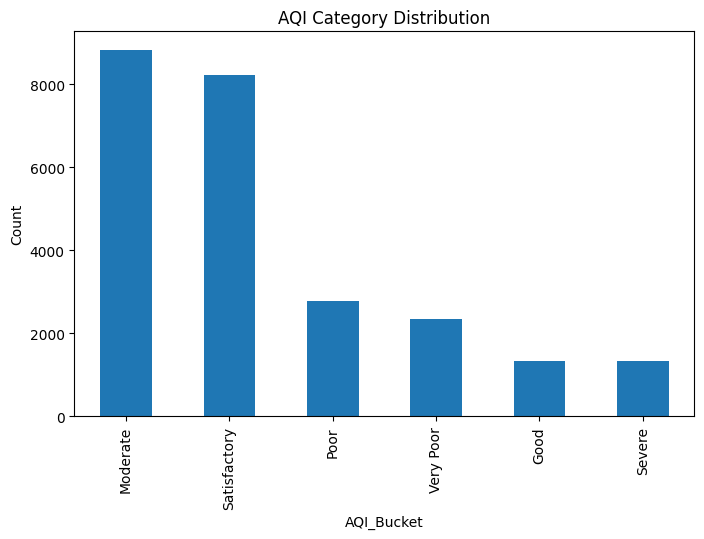


Cleaned dataset saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Dataset Size
print("Dataset Shape:")
print(df.shape)

# Step 2: Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 3: Remove Rows Without AQI
df = df.dropna(subset=['AQI'])

print("\nShape After Cleaning:")
print(df.shape)

# Step 4: Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Step 5: Basic Statistics
print("\nDataset Statistics:")
print(df.describe())

# Step 6: Top 10 Polluted Cities
top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

print("\nTop 10 Polluted Cities:")
print(top_cities)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top 10 Polluted Cities")
plt.ylabel("Average AQI")
plt.show()

# Step 7: AQI Trend
aqi_trend = df.groupby(df['Date'].dt.year)['AQI'].mean()

plt.figure(figsize=(8,5))
aqi_trend.plot(marker='o')
plt.title("AQI Trend Over Years")
plt.ylabel("Average AQI")
plt.show()

# Step 8: AQI Category Distribution
plt.figure(figsize=(8,5))
df['AQI_Bucket'].value_counts().plot(kind='bar')
plt.title("AQI Category Distribution")
plt.ylabel("Count")
plt.show()

# Step 9: Save Cleaned Dataset
df.to_csv("cleaned_city_day.csv", index=False)

print("\nCleaned dataset saved successfully!")

# Download cleaned dataset
files.download("cleaned_city_day.csv")

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features for prediction
features = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3']

data = df[features + ['AQI']].dropna()

X = data[features]
y = data['AQI']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# Show sample predictions
results = X_test.copy()
results['Actual AQI'] = y_test
results['Predicted AQI'] = predictions

print("\nSample Predictions:")
print(results[['Actual AQI','Predicted AQI']].head(10))

Mean Absolute Error: 14.482925170068027
R2 Score: 0.9346254536779085

Sample Predictions:
       Actual AQI  Predicted AQI
16441        80.0          84.27
2387         54.0          61.12
2932         86.0         114.94
16858       118.0         126.43
26671        61.0          67.04
10696       235.0         201.82
15032       125.0         113.99
18898       277.0         298.89
5778        130.0         120.14
27396        57.0          55.02


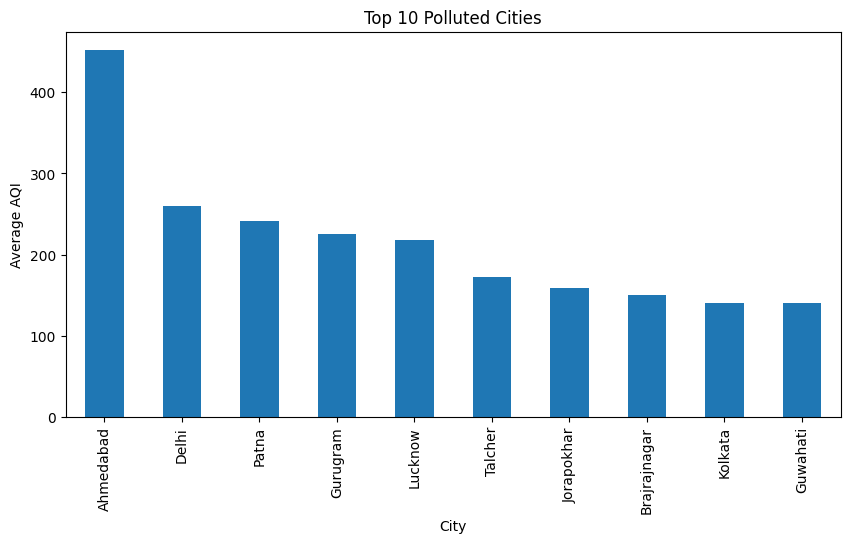

In [9]:
plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top 10 Polluted Cities")
plt.ylabel("Average AQI")
plt.savefig("top_polluted_cities.png", bbox_inches="tight")
plt.show()